# Cross-Validation & Classification

## Tuba Aksoy

## TUBA AKSOY

### Applied 1:

#### 1- Cross-Validation & Interpretation. For this problem, you can consider binary classi cation of the digits 3 and 8.

(i) Code up K-fold cross-validation (from scratch) and use your function to tune hyper-parameters
for sparse logistic regression and linear SVMs. Plot the cross-validation error curve along with the
training and test error. Compare which hyperparameters your cross-validation procedure selects to
those from built in functions. Re
ect on your results. Hint: You may consider using the logistic log-
likelihood or binomial deviance loss instead of the miss-classi cation error for this problem.m

In [164]:
import idx2numpy
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

train_images = idx2numpy.convert_from_file("train-images.idx3-ubyte")
train_labels = idx2numpy.convert_from_file("train-labels.idx1-ubyte")
test_images = idx2numpy.convert_from_file("t10k-images.idx3-ubyte")
test_labels = idx2numpy.convert_from_file("t10k-labels.idx1-ubyte")

train_images = train_images.astype(np.float32)
train_labels = train_labels.astype(np.int64)
test_images = test_images.astype(np.float32)
test_labels = test_labels.astype(np.int64)

# Print the shapes
print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [94]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from scipy.sparse import csr_matrix

binary_train_images = train_images[np.isin(train_labels, [3, 8])]
binary_train_labels = train_labels[np.isin(train_labels, [3, 8])]
binary_test_images = test_images[np.isin(test_labels, [3, 8])]
binary_test_labels = test_labels[np.isin(test_labels, [3, 8])]

# Flatten and normalize 
binary_train_images = binary_train_images.reshape(binary_train_images.shape[0], -1) / 255.0
binary_test_images = binary_test_images.reshape(binary_test_images.shape[0], -1) / 255.0

binary_train_labels = (binary_train_labels == 8).astype(int)
binary_test_labels = (binary_test_labels == 8).astype(int)


In [95]:
#  K-Fold Cross-Validation function
def k_fold_cross_validation(X, y, k, model):
    n_samples = X.shape[0]
    fold_size = n_samples // k
    cv_errors = []
    train_errors = []
    test_errors = []

    for fold in range(k):
        start = fold * fold_size
        end = (fold + 1) * fold_size

        X_test = X[start:end]
        y_test = y[start:end]

        X_train = np.concatenate((X[:start], X[end:]), axis=0)
        y_train = np.concatenate((y[:start], y[end:]), axis=0)

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        cv_accuracy = accuracy_score(y_test, y_test_pred)
        train_accuracy = accuracy_score(y_train, y_train_pred)

        cv_errors.append(1 - cv_accuracy)
        train_errors.append(1 - train_accuracy)

        # Calculate test error 
        y_test_pred_all = model.predict(binary_test_images.reshape(-1, 784))
        test_accuracy = accuracy_score(binary_test_labels, y_test_pred_all)
        test_errors.append(1 - test_accuracy)

    return cv_errors, train_errors, test_errors


In [104]:
# Hyperparameter tuning for Logistic Regression
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10]
lr_cv_errors = []
lr_train_errors = []
lr_test_errors = []

for C in C_values:
    lr_model = LogisticRegression(C=C, max_iter=10000)  
    cv_err, train_err, test_err = k_fold_cross_validation(binary_train_images.reshape(-1, 784), binary_train_labels, 5, lr_model)
    lr_cv_errors.append(np.mean(cv_err))
    lr_train_errors.append(np.mean(train_err))
    lr_test_errors.append(np.mean(test_err))


In [105]:
# Hyperparameter tuning for Linear SVM 
C_values = [0.0001, 0.001, 0.01, 0.1, 1,10]
svm_cv_errors = []
svm_train_errors = []
svm_test_errors = []

for C in C_values:
    svm_model = LinearSVC(C=C, max_iter=10000, dual=False)
    cv_err, train_err, test_err = k_fold_cross_validation(binary_train_images.reshape(-1, 784), binary_train_labels, 5, svm_model)
    svm_cv_errors.append(np.mean(cv_err))
    svm_train_errors.append(np.mean(train_err))
    svm_test_errors.append(np.mean(test_err))

In [106]:
# Choose the best hyperparameters
best_C_lr = C_values[np.argmin(lr_cv_errors)]
best_C_svm = C_values[np.argmin(svm_cv_errors)]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(binary_train_images.reshape(-1, 784))
X_test_scaled = scaler.transform(binary_test_images.reshape(-1, 784))

# Train the final models with the best hyperparameters
final_lr_model = LogisticRegression(C=best_C_lr, max_iter=10000)
final_lr_model.fit(X_train_scaled, binary_train_labels)

final_svm_model = LinearSVC(C=best_C_svm, max_iter=10000, dual=False)
final_svm_model.fit(X_train_scaled, binary_train_labels)

# Evaluate the final models on the test set
test_lr_pred = final_lr_model.predict(X_test_scaled)
test_svm_pred = final_svm_model.predict(X_test_scaled)

test_lr_error = 1 - accuracy_score(binary_test_labels, test_lr_pred)
test_svm_error = 1 - accuracy_score(binary_test_labels, test_svm_pred)


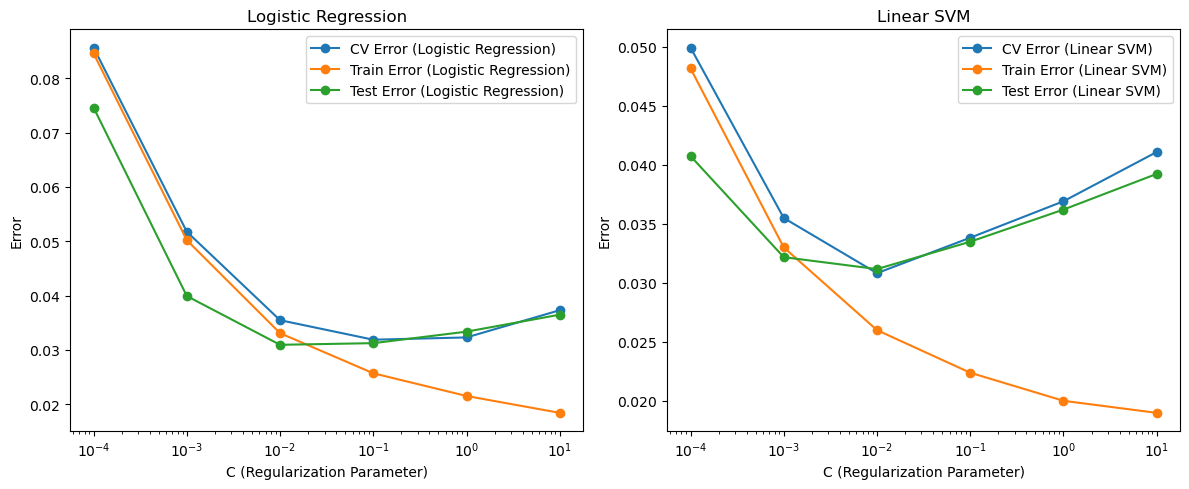

In [108]:
# Plot the errors
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(C_values, lr_cv_errors, marker='o', label='CV Error (Logistic Regression)')
plt.plot(C_values, lr_train_errors, marker='o', label='Train Error (Logistic Regression)')
plt.plot(C_values, lr_test_errors, marker='o', label='Test Error (Logistic Regression)')
plt.title('Logistic Regression')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Error')
plt.xscale('log')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(C_values, svm_cv_errors, marker='o', label='CV Error (Linear SVM)')
plt.plot(C_values, svm_train_errors, marker='o', label='Train Error (Linear SVM)')
plt.plot(C_values, svm_test_errors, marker='o', label='Test Error (Linear SVM)')
plt.title('Linear SVM')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Error')
plt.xscale('log')
plt.legend()

plt.tight_layout()
plt.show()


In [220]:
# Print the best hyperparameters and test errors
print("FROM SCRATCH BEST PARAMETERS")

print("Best C for Logistic Regression:", best_C_lr)
print("Best C for Linear SVM:", best_C_svm)
print("Test Error for Logistic Regression:", test_lr_error)
print("Test Error for Linear SVM:", test_svm_error)


FROM SCRATCH BEST PARAMETERS
Best C for Logistic Regression: 0.1
Best C for Linear SVM: 0.01
Test Error for Logistic Regression: 0.034778225806451624
Test Error for Linear SVM: 0.03578629032258063


In [98]:
#LOGISTIC REGRESSION MODEL

from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Create model with a list of C values
logistic_sparse_cv_model = LogisticRegressionCV(Cs=[0.0001, 0.001, 0.01, 0.1, 1, 10], cv=5, max_iter=10000)

# Fit the model 
logistic_sparse_cv_model.fit(csr_matrix(binary_train_images), binary_train_labels)

# Get the best C value 
best_C_sparse_logistic = logistic_sparse_cv_model.C_[0]




In [101]:
# SVM MODEL
param_grid_svm = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'kernel': ['linear'],
}

# Create model for SVM with cross-validation
svm_cv_model = GridSearchCV(SVC(), param_grid_svm, cv=5)

# Fit the SVM model 
svm_cv_model.fit(csr_matrix(binary_train_images), binary_train_labels)

# Get the best C value 
best_C_sparse_svm = svm_cv_model.best_params_['C']

print("Best C for Sparse Logistic Regression:", best_C_sparse_logistic)
print("Best C for Linear SVM with Sparse Data:", best_C_sparse_svm)

Best C for Sparse Logistic Regression: 0.1
Best C for Linear SVM with Sparse Data: 0.1


In [223]:
# Print the best hyperparameters 
print("FROM SCRATCH BEST PARAMETERS")
print("Best C for Logistic Regression:", best_C_lr)
print("Best C for Linear SVM:", best_C_svm)


print("BUILT IN BEST PARAMETERS")
print("Best C for Sparse Logistic Regression:", best_C_sparse_logistic)
print("Best C for Linear SVM with Sparse Data:", best_C_sparse_svm)

FROM SCRATCH BEST PARAMETERS
Best C for Logistic Regression: 0.1
Best C for Linear SVM: 0.01
BUILT IN BEST PARAMETERS
Best C for Sparse Logistic Regression: 0.1
Best C for Linear SVM with Sparse Data: 0.1


(ii) Interpret your sparse logistic regression and linear SVM model selected via cross-validation. Which
features are most important? Which observations are particularly di cult or easy to classify? Visualize
and discuss your results.

In [120]:
import numpy as np
import matplotlib.pyplot as plt

# Feature names 
feature_names = [f"Feature {i}" for i in range(len(X_train_scaled[0]))] 

# Get feature importances 
lr_feature_importance = final_lr_model.coef_[0]
svm_feature_importance = final_svm_model.coef_[0]

# Sort features by importance 
lr_sorted_indices = np.argsort(np.abs(lr_feature_importance))[::-1]
svm_sorted_indices = np.argsort(np.abs(svm_feature_importance))[::-1]

num_top_features = 5  

print("Top Features for Logistic Regression:")
for i in range(num_top_features):
    feature_idx = lr_sorted_indices[i]
    print(f"{feature_names[feature_idx]}: {lr_feature_importance[feature_idx]}")

print("\nTop Features for Linear SVM:")
for i in range(num_top_features):
    feature_idx = svm_sorted_indices[i]
    print(f"{feature_names[feature_idx]}: {svm_feature_importance[feature_idx]}")




Top Features for Logistic Regression:
Feature 507: -0.5752199985884096
Feature 591: -0.4256266307537397
Feature 513: 0.42383339089673605
Feature 317: 0.4192216053641876
Feature 290: 0.4172381814048181

Top Features for Linear SVM:
Feature 507: -0.19908397044451226
Feature 591: -0.13872030115182996
Feature 513: 0.13079421364580102
Feature 276: 0.13041394682743587
Feature 386: 0.12592100107725376


In [112]:
#MISCLASSIFIED AND CORRECT PREDICTIONS
#CONFUSION MATRIX

import numpy as np
from sklearn.metrics import confusion_matrix

misclassified_indices_lr = np.where(test_lr_pred != binary_test_labels)[0]
misclassified_indices_svm = np.where(test_svm_pred != binary_test_labels)[0]

# Create a confusion matrix 
cm_lr = confusion_matrix(binary_test_labels, test_lr_pred)
cm_svm = confusion_matrix(binary_test_labels, test_svm_pred)

# Display misclassified indices 
print("Misclassified Samples for Logistic Regression:")
print(misclassified_indices_lr)
print("\nMisclassified Samples for Linear SVM:")
print(misclassified_indices_svm)

# Display confusion matrix
print("\nConfusion Matrix for Logistic Regression:")
print(cm_lr)
print("\nConfusion Matrix for Linear SVM:")
print(cm_svm)


Misclassified Samples for Logistic Regression:
[  25   87   94   97  111  133  160  161  216  218  232  261  300  371
  372  376  380  399  422  424  455  465  480  482  486  552  581  592
  599  645  707  719  728  781  783  802  890  904  915  943  949  970
  987  995 1007 1012 1085 1132 1175 1179 1187 1192 1195 1197 1214 1432
 1577 1591 1636 1644 1647 1649 1807 1848 1965 1970 1976 1980 1981]

Misclassified Samples for Linear SVM:
[   0   87   94   97  111  133  160  161  216  218  232  237  261  300
  371  372  399  422  424  455  465  480  482  486  552  581  592  599
  645  654  707  719  728  781  783  802  890  904  907  915  943  949
  964  970  987  995 1007 1012 1132 1175 1179 1187 1192 1195 1197 1214
 1308 1432 1577 1591 1636 1644 1647 1649 1807 1848 1965 1970 1976 1980
 1981]

Confusion Matrix for Logistic Regression:
[[974  36]
 [ 33 941]]

Confusion Matrix for Linear SVM:
[[972  38]
 [ 33 941]]


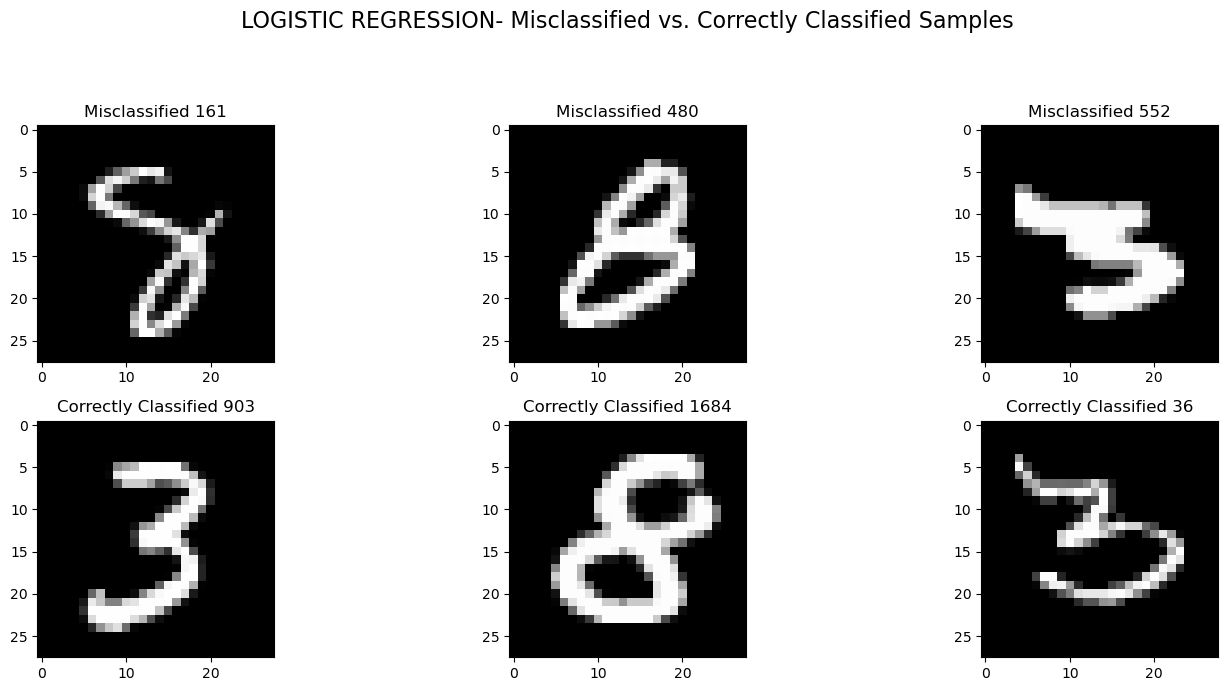

In [163]:
#VISUALIZE DIGITS 

import numpy as np
import matplotlib.pyplot as plt

# Identify misclassified samples
misclassified_indices = np.where(test_lr_pred != binary_test_labels)[0]

# Randomly select a subset of misclassified samples 
num_samples_to_visualize = 3
random_misclassified_indices = np.random.choice(misclassified_indices, num_samples_to_visualize, replace=False)

# Visualize misclassified samples and compare 
plt.figure(figsize=(15, 7))

for i, index in enumerate(random_misclassified_indices):
    plt.subplot(2, num_samples_to_visualize, i + 1)
    plt.imshow(binary_test_images[index].reshape(28, 28), cmap='gray')
    plt.title(f'Misclassified {index}')

    correctly_classified_indices = np.where(test_lr_pred == binary_test_labels)[0]
    random_correctly_classified_index = np.random.choice(correctly_classified_indices, 1)
    plt.subplot(2, num_samples_to_visualize, i + num_samples_to_visualize + 1)
    plt.imshow(binary_test_images[random_correctly_classified_index].reshape(28, 28), cmap='gray')
    plt.title(f'Correctly Classified {random_correctly_classified_index[0]}')

# Add a title at the top
plt.suptitle("LOGISTIC REGRESSION- Misclassified vs. Correctly Classified Samples", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.92])  
plt.show()


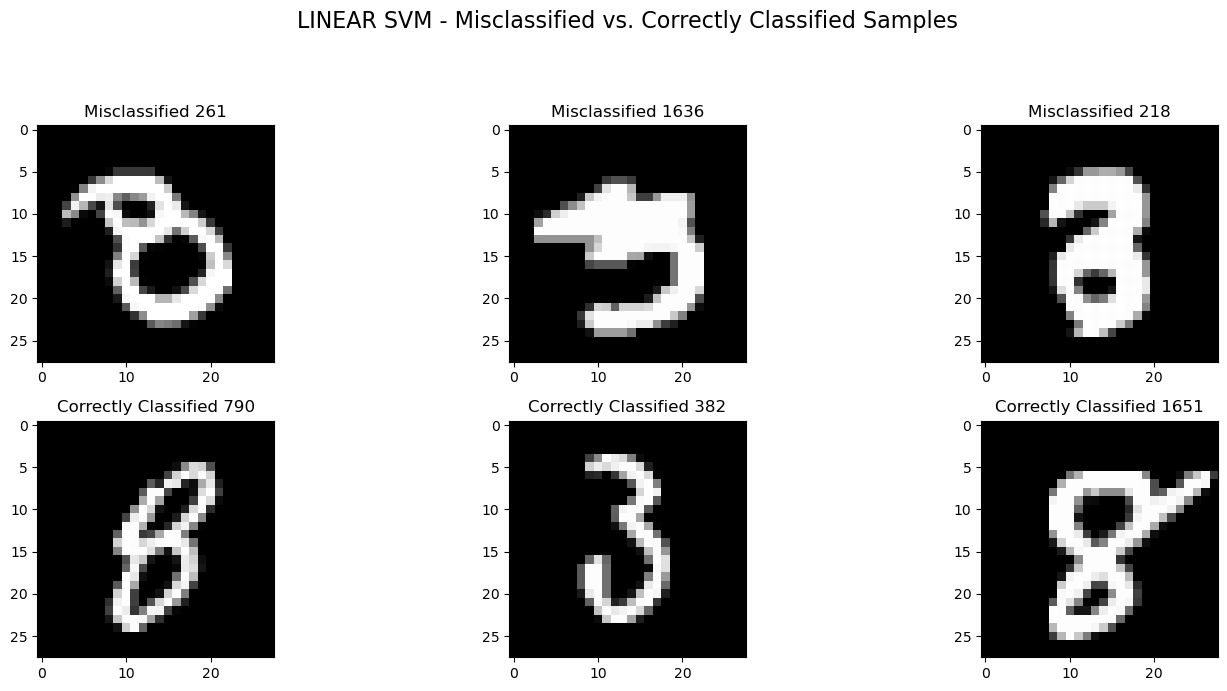

In [158]:
import numpy as np
import matplotlib.pyplot as plt

# Identify misclassified samples
misclassified_indices = np.where(test_svm_pred != binary_test_labels)[0]

# Randomly select a subset of misclassified samples 
num_samples_to_visualize = 3
random_misclassified_indices = np.random.choice(misclassified_indices, num_samples_to_visualize, replace=False)

# Visualize misclassified samples and compare 
plt.figure(figsize=(15, 7))

for i, index in enumerate(random_misclassified_indices):
    plt.subplot(2, num_samples_to_visualize, i + 1)
    plt.imshow(binary_test_images[index].reshape(28, 28), cmap='gray')
    plt.title(f'Misclassified {index}')

    correctly_classified_indices = np.where(test_svm_pred == binary_test_labels)[0]
    random_correctly_classified_index = np.random.choice(correctly_classified_indices, 1)
    plt.subplot(2, num_samples_to_visualize, i + num_samples_to_visualize + 1)
    plt.imshow(binary_test_images[random_correctly_classified_index].reshape(28, 28), cmap='gray')
    plt.title(f'Correctly Classified {random_correctly_classified_index[0]}')


plt.suptitle("LINEAR SVM - Misclassified vs. Correctly Classified Samples", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.92])  # Adjust subplot layout to make room for the title
plt.show()


### Applied 1
### Reflection

#### Compare which hyperparameters your cross-validation procedure selects to those from built in functions
The hyperparameters selected for Logistic regression is same for both the algorithm from scratch and the algorithm that uses built in function, which is 0.1. For Linear SVM, the from-scratch-algorithm selects 0.01 while built-in-algorithm selects 0.1. 
I used the sme iterations and same hyperparameter values for both algorithm. This might be because of the built in function used different evaluation metircs to pick the 0.1 hyperparameter. 
If we look at the plot at the from-scratch-algorithm, at 0.1, i would say there is over fitting. The built in function might have a different approach and selection in that. 

#### COMPARING TOP FEATURES: 
If we compare the top 5 features between Logistic Regression and Linear SVM, the first 3 most important feature is the same in both models, which are: 507,591 and 513. This observation suggests that these features play a significant role in the classification decision for both models.

#### CONFUSION MATRIX: 
When we look at the confusion matrix above, both models have close deviation number from true value. This indicates that both models have a comparable level of accuracy and similar challenges in classifying certain samples.

#### VISUAL INSPECTION: 
When we visualize some of the numbers, the ones that are not symmetrical are more likely to be more easily misclassified. Also, the numbers that are not completely drawn are mostly misclassified. But this requires further analysis. Some digits or patterns might be more challenging to classify due to their visual characteristics.

### Applied 2:


#### 2. Multi-Class Classi cation. Compare and contrast the following methods for classifying all the digits:

Logistic (Multinomial Regression).
  Naive Bayes.
  Linear Discriminant Analysis.
  Linear SVMs (one vs. one or one vs. all approach).
  Kernel SVMs with at least two di erent kernel types. (Which kernels did you use and why?)
For each of these, you will need to use validation or cross-validation to select any hyperparameters.
Which method performs best in terms of test accuracy? Why? Provide a confusion matrix for clas-
sifying digits. Which digits are most often misclassi ed? Provide visualizations to help explain or
interpret the results of various methods. Re
ect on your results.

In [200]:
#LOGISTIC MULTINOMIAL REGRESSION

from sklearn.model_selection import GridSearchCV

# Reshape the data to 1D
train_images_1d = train_images.reshape(train_images.shape[0], -1)
test_images_1d = test_images.reshape(test_images.shape[0], -1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_images_scaled = scaler.fit_transform(train_images_1d)
test_images_scaled = scaler.transform(test_images_1d)


# Create model
logistic_regression = LogisticRegression(max_iter=50000, multi_class='multinomial')

#  hyperparameter tuning with cross-validation
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
grid_search = GridSearchCV(logistic_regression, param_grid, cv=5, scoring='accuracy')
grid_search.fit(train_images_scaled, train_labels)
best_logistic_regression = grid_search.best_estimator_

# Train the model
best_logistic_regression.fit(train_images_scaled, train_labels)

# Evaluate the model 
test_accuracy_logistic_regression = best_logistic_regression.score(test_images_scaled, test_labels)
print("Test Accuracy (Logistic Regression):", test_accuracy_logistic_regression)


Test Accuracy (Logistic Regression): 0.9263


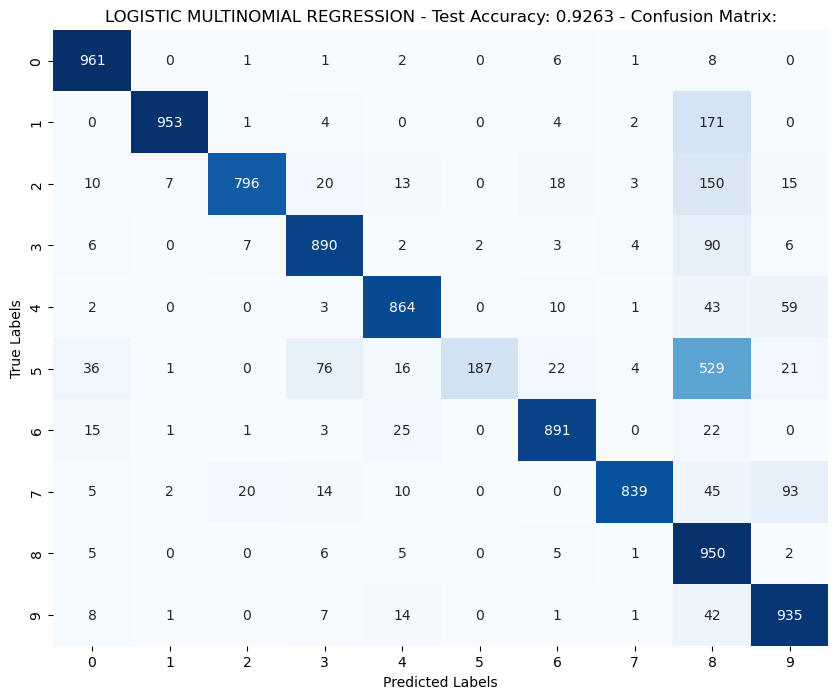

In [201]:
# LOGISTIC MULTINOMIAL REGRESSION - Test Accuracy: 0.9263 - Confusion Matrix:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict labels 
predicted_labels = best_logistic_regression.predict(test_images_1d)

# Generate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('LOGISTIC MULTINOMIAL REGRESSION - Test Accuracy: 0.9263 - Confusion Matrix:')
plt.show()


In [171]:
#NAIVE BAYES 

from sklearn.naive_bayes import MultinomialNB

# Create model
naive_bayes = MultinomialNB()

# Train the model
naive_bayes.fit(train_images_1d, train_labels)

# Evaluate the model 
test_accuracy_naive_bayes = naive_bayes.score(test_images_1d, test_labels)
print("Test Accuracy (Naive Bayes):", test_accuracy_naive_bayes)


Test Accuracy (Naive Bayes): 0.8365


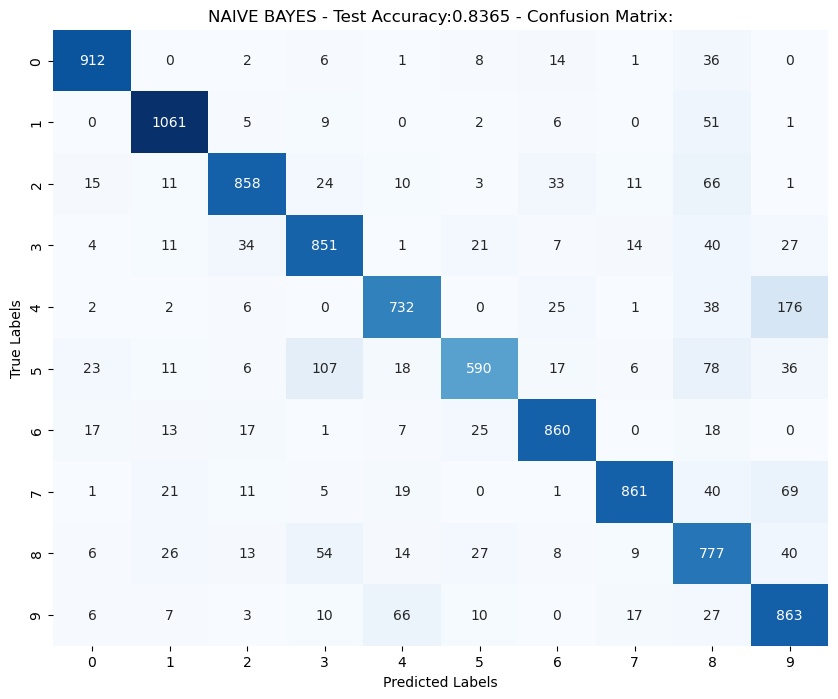

In [181]:
# NAIVE BAYES - Test Accuracy:0.8365 - Confusion Matrix:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict labels 
predicted_labels = naive_bayes.predict(test_images_1d)

# Confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('NAIVE BAYES - Test Accuracy:0.8365 - Confusion Matrix:')
plt.show()


In [173]:
#LINEAR DISCRIMINANT ANALYSIS 

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Create model
lda = LinearDiscriminantAnalysis()

# Train the model
lda.fit(train_images_1d, train_labels)

# Evaluate the model on the test dataset
test_accuracy_lda = lda.score(test_images_1d, test_labels)
print("Test Accuracy (LDA):", test_accuracy_lda)


Test Accuracy (LDA): 0.873


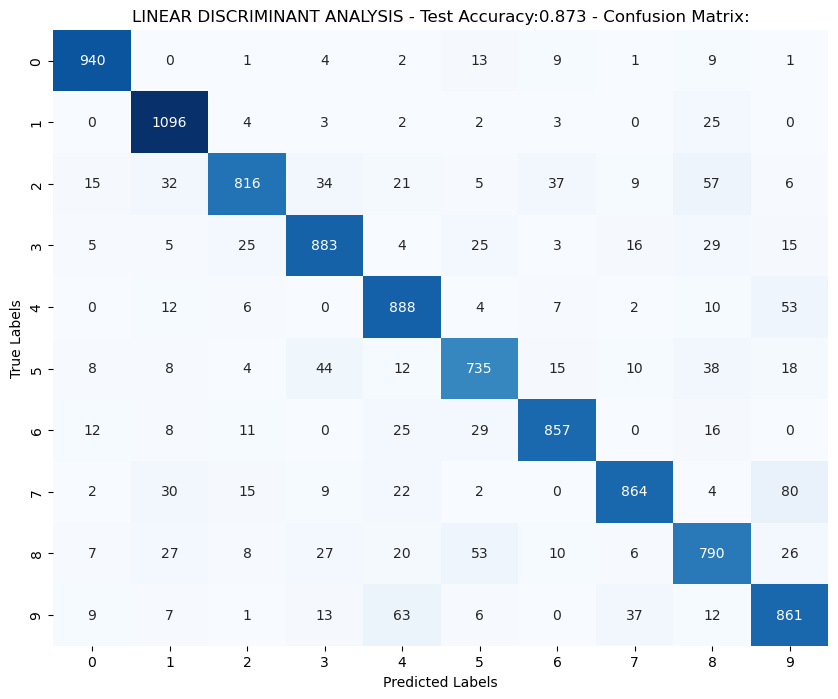

In [183]:
#LINEAR DISCRIMINANT ANALYSIS - Test Accuracy:0.873 - Confusion Matrix:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict labels 
predicted_labels = lda.predict(test_images_1d)

# Generate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('LINEAR DISCRIMINANT ANALYSIS - Test Accuracy:0.873 - Confusion Matrix:')
plt.show()

In [208]:
#LINEAR SVM  (One vs. All)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_images_scaled = scaler.fit_transform(train_images_1d)
test_images_scaled = scaler.transform(test_images_1d)   

linear_svm = LinearSVC(max_iter=50000, dual= False)

# hyperparameter tuning 
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid_search = GridSearchCV(linear_svm, param_grid, cv=5, scoring='accuracy')
grid_search.fit(train_images_scaled, train_labels)

# best hyperparameters
best_linear_svm = grid_search.best_estimator_

# Train the model 
best_linear_svm.fit(train_images_scaled, train_labels)

# Evaluate the model 
test_accuracy_linear_svm = best_linear_svm.score(test_images_scaled, test_labels)
print("Test Accuracy (Linear SVM - One vs. All):", test_accuracy_linear_svm)



Test Accuracy (Linear SVM - One vs. All): 0.9158


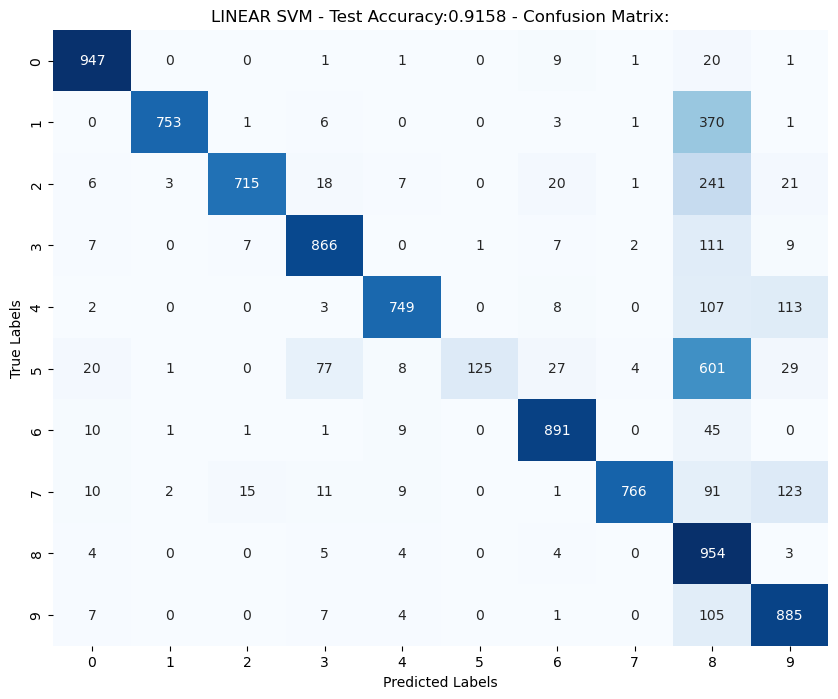

In [209]:
# LINEAR SVM - Test Accuracy:0.873 - Confusion Matrix:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict labels 
predicted_labels = best_linear_svm.predict(test_images_1d)

confusion_mtx = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('LINEAR SVM - Test Accuracy:0.9158 - Confusion Matrix:')
plt.show()

In [190]:
# KERNEL SVM (RBF) & (Polynomial)

from sklearn.svm import SVC

#  RBF kernel
rbf_svm = SVC(kernel='rbf', gamma='scale')

# Train 
rbf_svm.fit(train_images_1d, train_labels)

# Evaluate 
test_accuracy_rbf_svm = rbf_svm.score(test_images_1d, test_labels)
print("Test Accuracy (Kernel SVM - RBF Kernel):", test_accuracy_rbf_svm)

#  Polynomial kernel
poly_svm = SVC(kernel='poly', degree=3, gamma='scale')

# Train 
poly_svm.fit(train_images_1d, train_labels)

# Evaluate 
test_accuracy_poly_svm = poly_svm.score(test_images_1d, test_labels)
print("Test Accuracy (Kernel SVM - Polynomial Kernel):", test_accuracy_poly_svm)


Test Accuracy (Kernel SVM - RBF Kernel): 0.9792
Test Accuracy (Kernel SVM - Polynomial Kernel): 0.9771


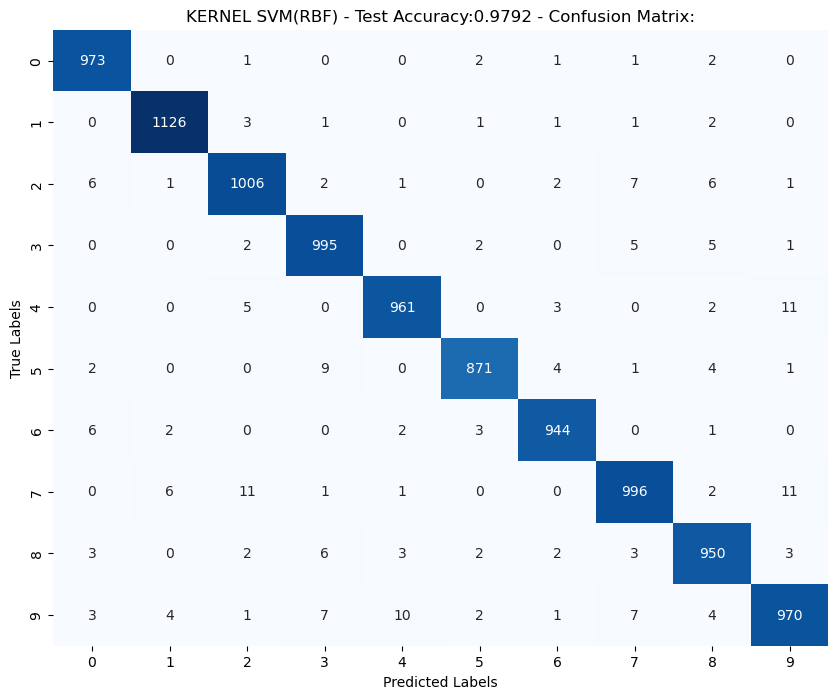

In [210]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict labels on the test dataset
predicted_labels = rbf_svm.predict(test_images_1d)

# Generate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('KERNEL SVM(RBF) - Test Accuracy:0.9792 - Confusion Matrix:')
plt.show()

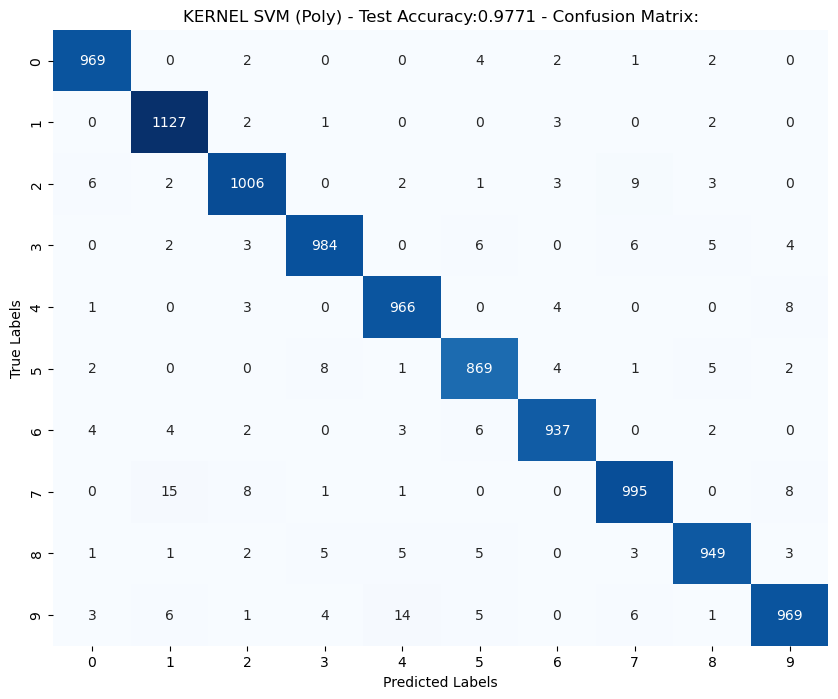

In [215]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict labels 
predicted_labels = poly_svm.predict(test_images_1d)

confusion_mtx = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('KERNEL SVM (Poly) - Test Accuracy:0.9771 - Confusion Matrix:')
plt.show()

### Which kernels did you use and why

I used  Radial Basis Function (RBF) kernel and the Polynomial kernel because they use different approaches to capture non-linear relationships in the data, and I wanted to compare their performances in this data. And they are commonly used kernel functions. 

RBF is highly flexible and can capture complex, non-linear relationships in the data. it is also a universal Approximator for appropriate hyperparameters. It is commonly used in image classifications. 

The Polynomial kernel is a good option for capturing non-linear relationships. The degree of the polynomial helps for the control of the non-linearity. We can increase the degree to fit more complex patterns.

### Reflection:


#### Which method performs best in terms of test accuracy? Why?

Kernel SVMs performs best in terms of test accuracy. 

1- Kernel SVMs are good for fitting to complex parameters.The MNIST dataset consists of handwritten digits, which are non-linearly. Kernel SVMs can handle non-linear relationships between data points by mapping the original feature space into a higher-dimensional space through a kernel function. 

2-It is a high-dimensional data. Kernel SVMs can perform dimensionality reduction in the transformed space. it focuses on relevant features and ignoring irrelevant ones.

3- SVMs is good at controlling the complexity of the model by choosing different kernel functions and tuning hyperparameters like the cost parameter C. it helps to find the right balance between bias and variance for your specific dataset. I might be leading to a better generalization.

4- SVMs are known to handle outliers well. This data consists hand written digits which has many outliers, so, that might be one reason. 


#### Which digits are most often misclassifed?

Number 5 is most often misclassified, it is actually misclassified in every model. 

Below I show the visualization of two models:

1- Linear SVM: This model seems to predict number 5 very poorly compared to other models. Although it's accuracy in overall prediction is over 0.9, it seems to confuse digit 5 with digits 8 and 3. We can see that even very clearly written digit 5 can be misclassified in this model. It seems to do a better job classifying other digits. 
it looks like the model misclassifies especially when the angle of the digits are different. SO, that might be a feature that is learned wrong. If you look at digit 1, they all are lines, but the ones that are tilted to right are correctly classified. Similar issue at digit 2, when there is a v shape angle at the base, it is misclassified. Ocfourse there are many other features that are affecting like curvature of the latters or the location of the clines and curvatures. The reasons for misclassification require further analysis. 


2- Kernel SVM: Both kernels are visualized below. The misclassified digit 5s in these two modelare very off, I cant even tell that they are digit 5s. So, I can tell this models did a good job classifying digit 5. That is true for other digits as well. 

I see that these model made mistakes for especially differently written digits, like in number 7 and number 1, you can write them as like vertical lines, or add other horizantal lines to base (for 1) or to middle (for 7). Adding horizantal lines somewhat varies depending on countries, like in Europe it might be more common. So, I can say, this model fails on classifiying in those kind of situations. Or there are some numbers written again differently, they are also misclassified.  

Againg, ofcourse many relations can be found, but Kernel SVMs look like misclassifies mostly when there are extreme abnormalies.


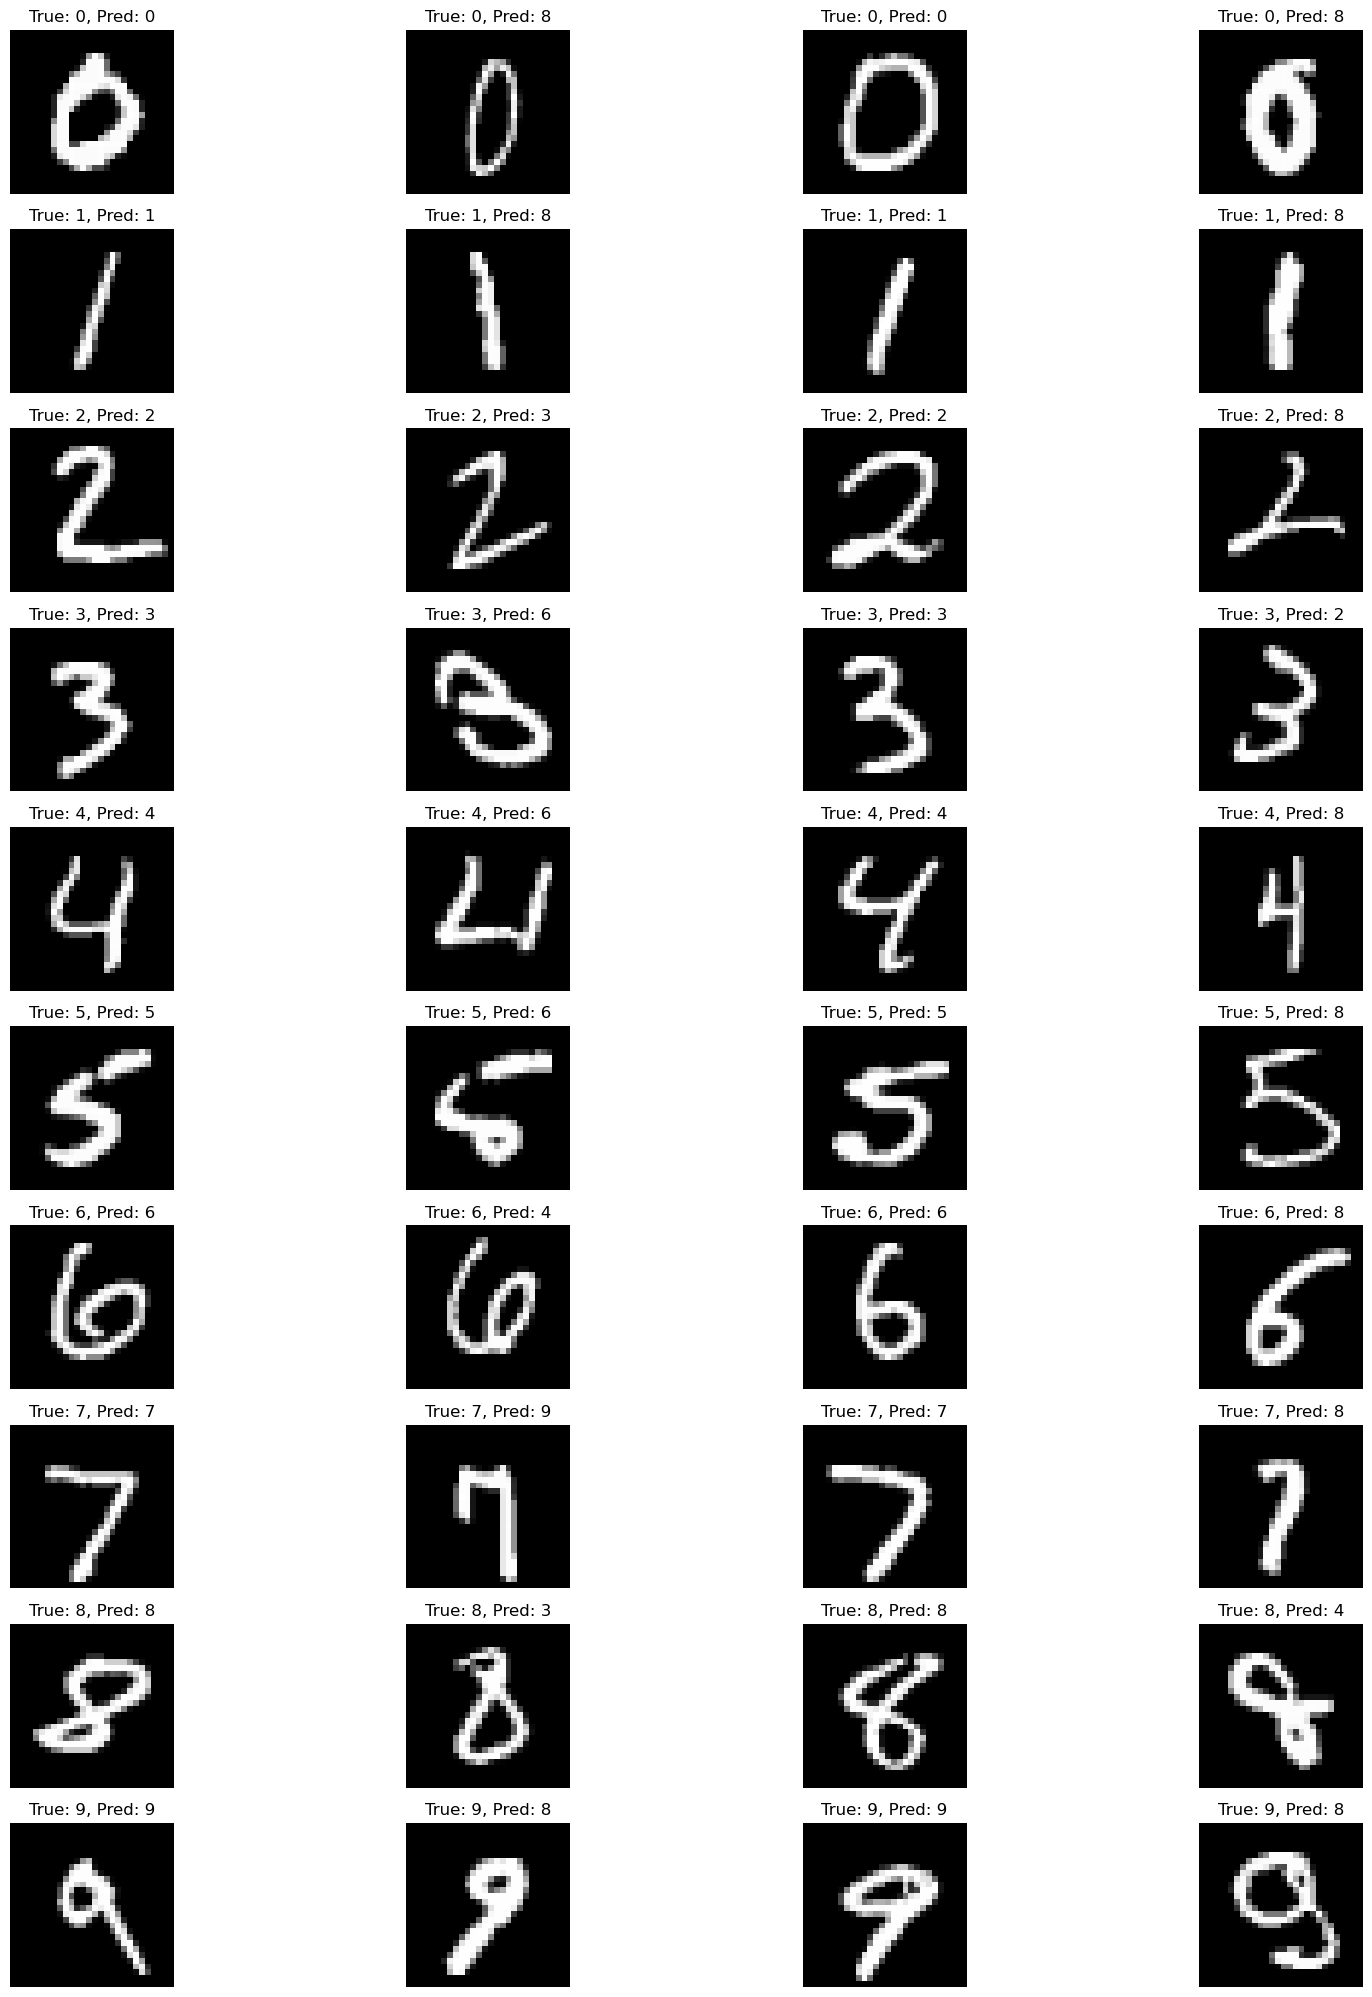

In [218]:
#LINEAR SVM MODEL
plt.figure(figsize=(16, 40))

# Predict labels on the test dataset
predicted_labels = best_linear_svm.predict(test_images_1d)

# Find indices of correctly and incorrectly classified 
correctly_classified_indices = np.where(predicted_labels == test_labels)
misclassified_indices = np.where(predicted_labels != test_labels)

# Visualize 2 correctly classified samples for each digit
for digit in range(10):
    digit_indices = correctly_classified_indices[0][test_labels[correctly_classified_indices] == digit]
    for i in range(2):
        plt.subplot(20, 4, digit * 4 + i * 2 + 1)
        plt.imshow(test_images[digit_indices[i]], cmap='gray')
        plt.title(f'True: {digit}, Pred: {predicted_labels[digit_indices[i]]}')
        plt.axis('off')

# Visualize 2 misclassified samples for each digit
for digit in range(10):
    digit_indices = misclassified_indices[0][test_labels[misclassified_indices] == digit]
    for i in range(2):
        plt.subplot(20, 4, digit * 4 + i * 2 + 2)
        plt.imshow(test_images[digit_indices[i]], cmap='gray')
        plt.title(f'True: {digit}, Pred: {predicted_labels[digit_indices[i]]}')
        plt.axis('off')

plt.tight_layout()
plt.show()


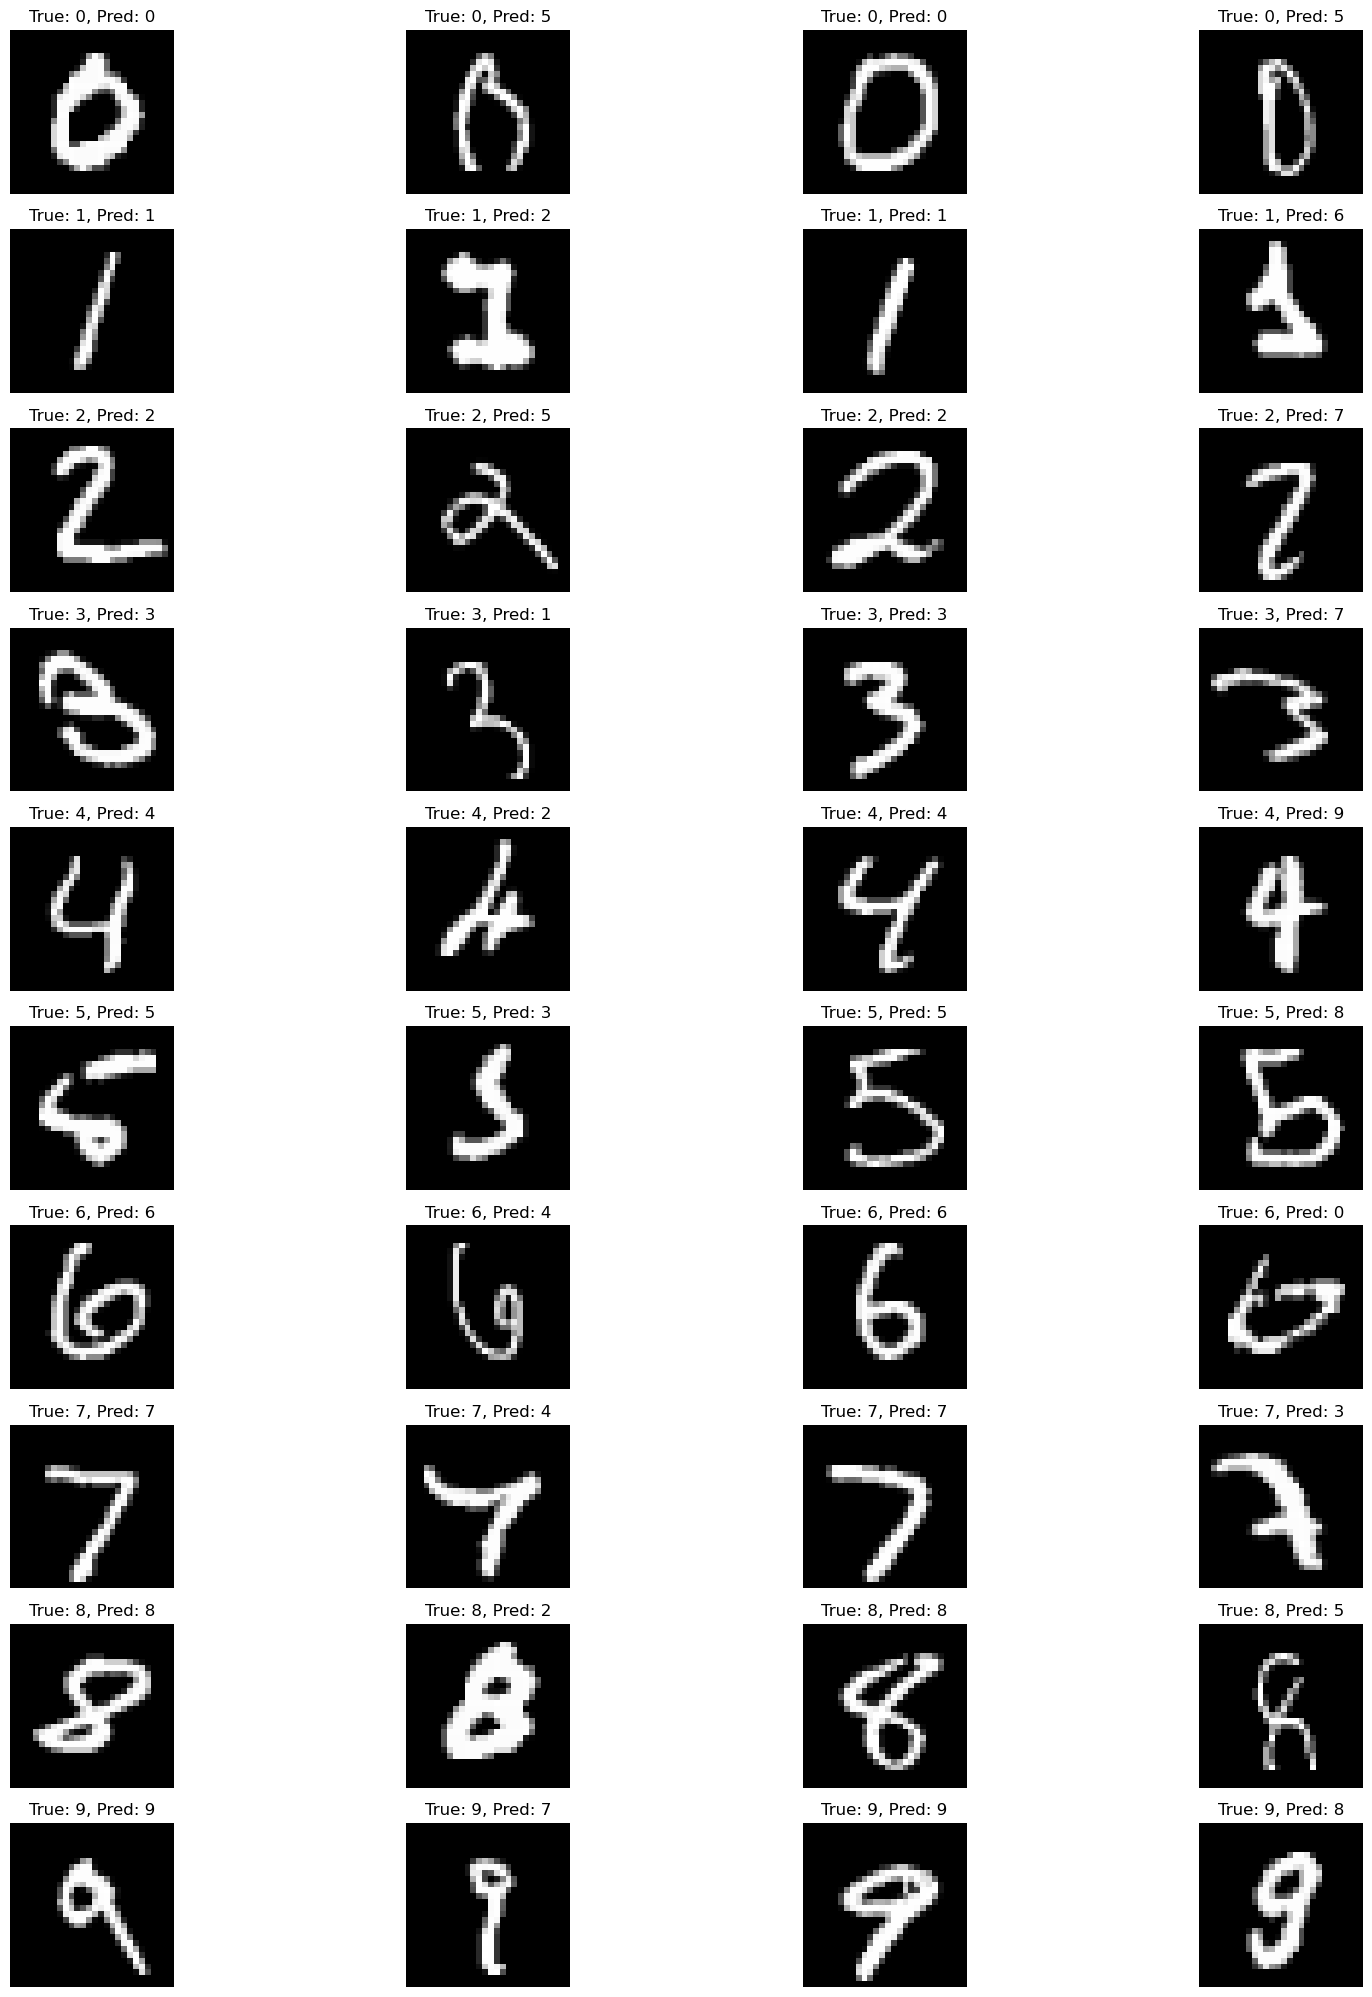

In [217]:
#KERNEL 1

plt.figure(figsize=(16, 40))

# Predict labels 
predicted_labels = poly_svm.predict(test_images_1d)

# Find indices of correctly and incorrectly classified samples
correctly_classified_indices = np.where(predicted_labels == test_labels)
misclassified_indices = np.where(predicted_labels != test_labels)

# Visualize 2 correctly classified samples for each digit
for digit in range(10):
    digit_indices = correctly_classified_indices[0][test_labels[correctly_classified_indices] == digit]
    for i in range(2):
        plt.subplot(20, 4, digit * 4 + i * 2 + 1)
        plt.imshow(test_images[digit_indices[i]], cmap='gray')
        plt.title(f'True: {digit}, Pred: {predicted_labels[digit_indices[i]]}')
        plt.axis('off')

# Visualize 2 misclassified samples for each digit
for digit in range(10):
    digit_indices = misclassified_indices[0][test_labels[misclassified_indices] == digit]
    for i in range(2):
        plt.subplot(20, 4, digit * 4 + i * 2 + 2)
        plt.imshow(test_images[digit_indices[i]], cmap='gray')
        plt.title(f'True: {digit}, Pred: {predicted_labels[digit_indices[i]]}')
        plt.axis('off')

plt.tight_layout()
plt.show()



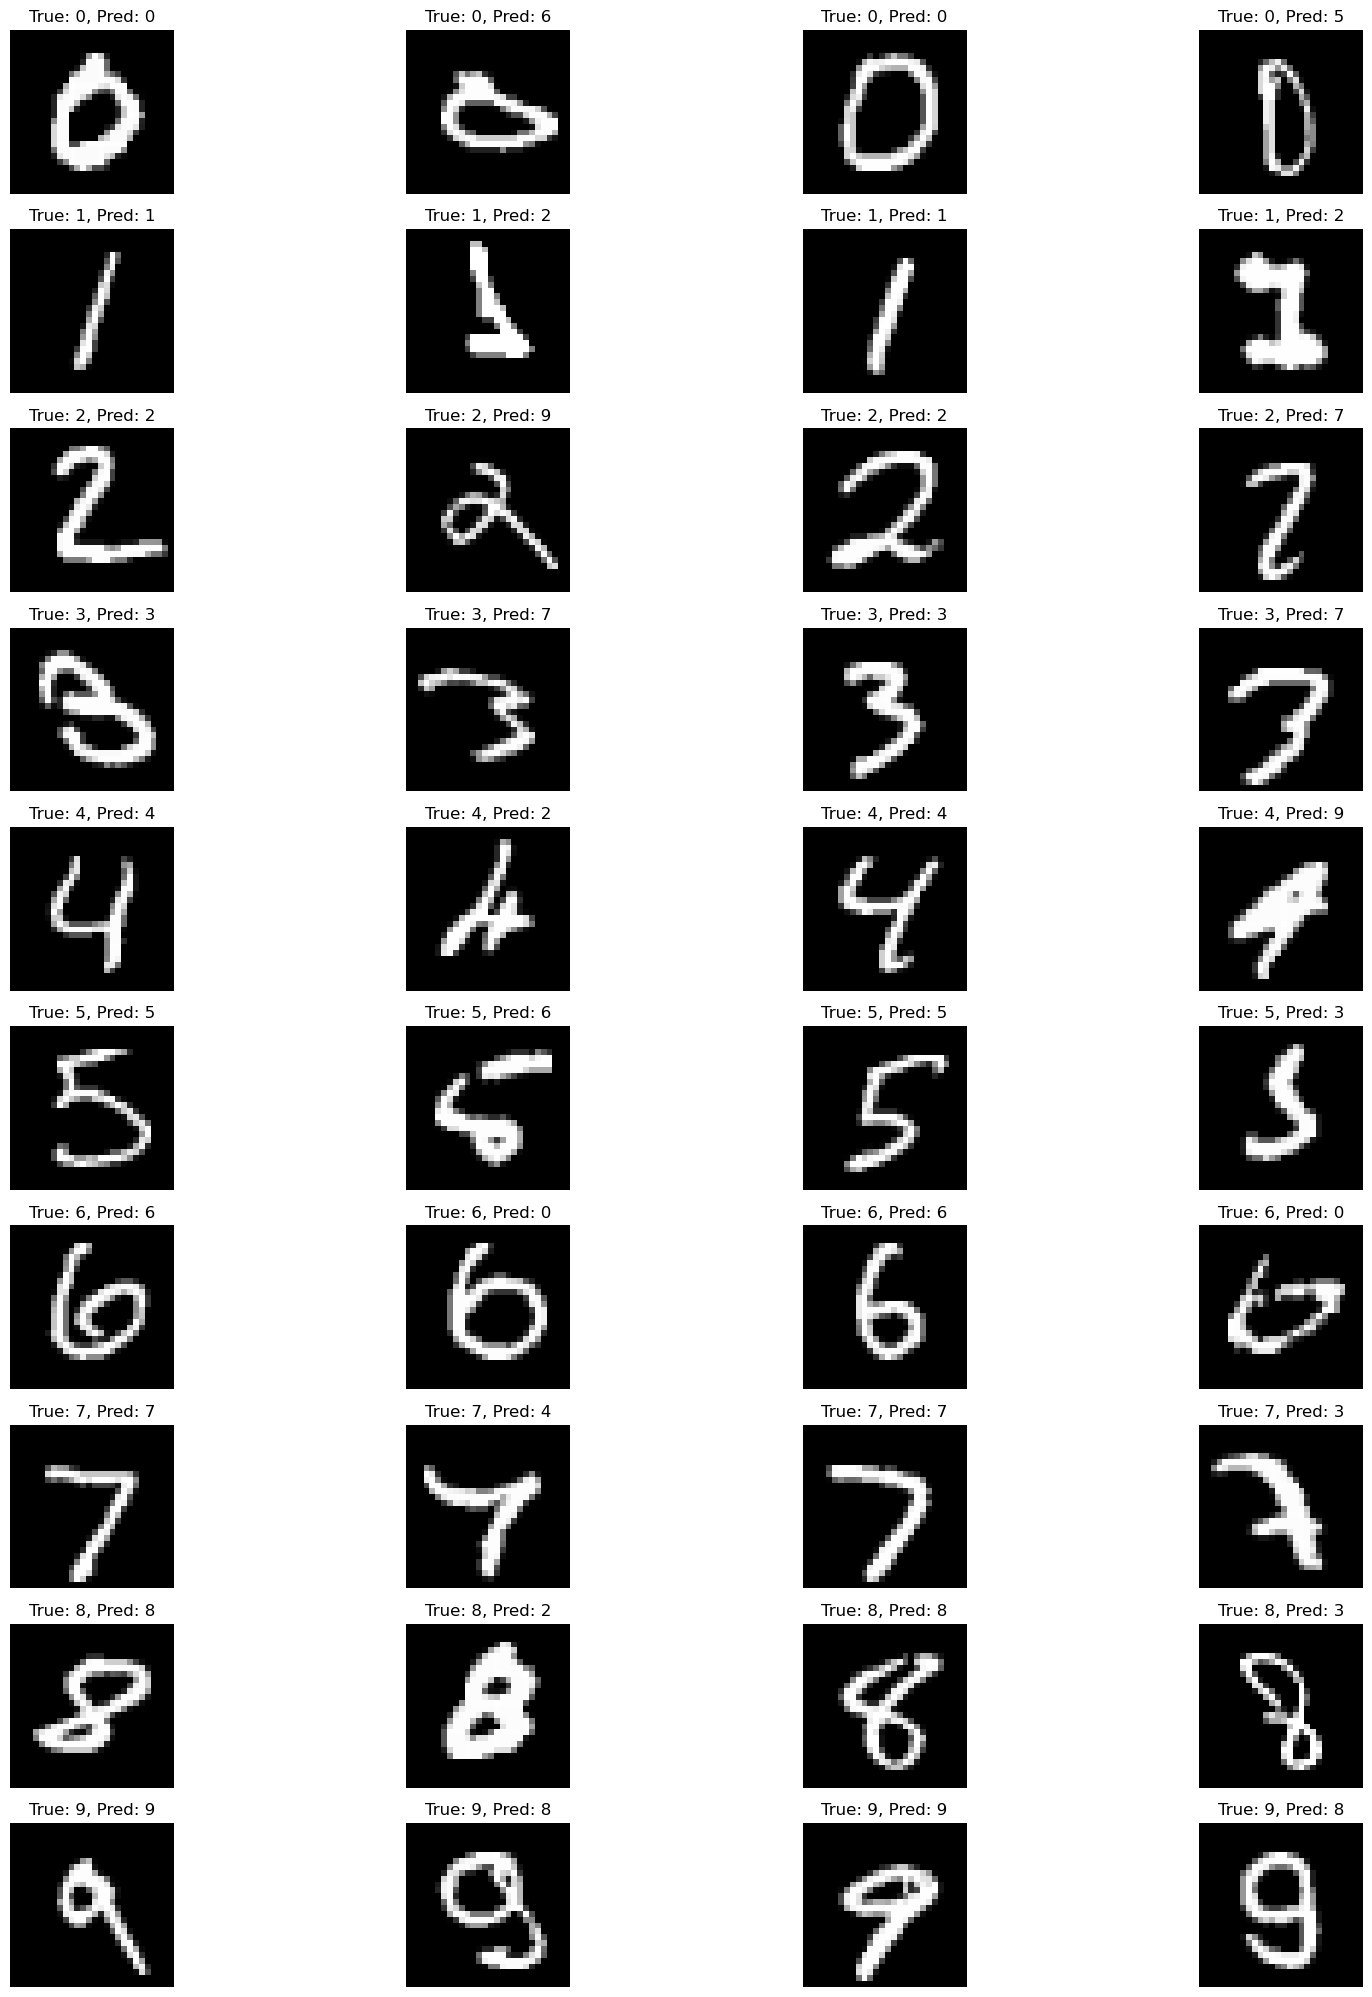

In [219]:
#KERNEL 2
plt.figure(figsize=(16, 40))

# Predict labels on the test dataset
predicted_labels = rbf_svm.predict(test_images_1d)

# Find indices of correctly and incorrectly classified samples
correctly_classified_indices = np.where(predicted_labels == test_labels)
misclassified_indices = np.where(predicted_labels != test_labels)

# Visualize 2 correctly classified samples for each digit
for digit in range(10):
    digit_indices = correctly_classified_indices[0][test_labels[correctly_classified_indices] == digit]
    for i in range(2):
        plt.subplot(20, 4, digit * 4 + i * 2 + 1)
        plt.imshow(test_images[digit_indices[i]], cmap='gray')
        plt.title(f'True: {digit}, Pred: {predicted_labels[digit_indices[i]]}')
        plt.axis('off')

# Visualize 2 misclassified samples for each digit
for digit in range(10):
    digit_indices = misclassified_indices[0][test_labels[misclassified_indices] == digit]
    for i in range(2):
        plt.subplot(20, 4, digit * 4 + i * 2 + 2)
        plt.imshow(test_images[digit_indices[i]], cmap='gray')
        plt.title(f'True: {digit}, Pred: {predicted_labels[digit_indices[i]]}')
        plt.axis('off')

plt.tight_layout()
plt.show()



### Conceptual 1:


1. Suppose a company has hourly readings from 800 sensors for a whole year that are used to monitor the workings of a large system of industrial equipment. Given some labeled anomalies, an engineer wants to build a classifier to predict anomalies from future readings of these sensors. She trains a machine learning model and uses 10-fold cross-validation to tune hyper-parameters (using vanilla methods from sklearn, for example). When new data comes in, however, the accuracy of the classifier is poor. She is confused as the cross-validation error was quite good. What might explain these results? If you were designing a procedure to train, tune, and validate a machine learning model for this problem, what would you suggest to do? Please be explicit in outlining your procedure and justify all choices.


### Answer:

The goal of machine learning is to generalize to NEW data and be able to predict for unseen data. However, in this example model performs good during cross-validation, but poorly on new, unseen data. There might be a couple of problems that leads to this problem.

First I will go over generic problems for this kind of a situation, then talk about anomaly detection. 



#### 1-Overfitting: 
This might be due to overfitting. That happens when a model learns to perform extremely well on the training data but performs badly on new data. During overfitting the model becomes too complex, and it captures noise in the training data, which is the data that is not informative but random. Since the model actually did not learn the patterns depending on the features, but only memorized the training data, when a new data is introduced, the model makes mistakes because of overfitting to training data. 

#### 2-Data Leakage: 

Also there might be data leakage during cross validation while tuning the parameters. This can be resolved by splitting the data into train, test, and validation groups. The train data should be used for model fitting while validation data should be used for hyperparameter tuning and selecting the best parameter. Test data must be used only for evaluating the prediction. We cannot use test data to tune the parameters or model fitting. 

While doing 10-fold cross validation, what we can do is, split our data into a training set (80%) and a separate test set (20%). We can do nested cross validation to prevent data leakage. The outer loop performs K-fold cross-validation, and the inner loop performs another K-fold cross-validation for hyperparameter selection. This helps prevent overfitting to the validation data during hyperparameter tuning.


#### 3-Try Different Methods: 

Other than hyperparameter tuning, trying out different models might solve the problem. What I would do is to try other methods and tune for the best hyperparameters without peeking into test data and preventing overfitting. We can try supervised and also unsupervised techniques for best results. 

#### 4-Feature Engineering: 
Also, there might be some features that are not informative by themselves. Those features can be turned into more meaningful features by feature engineering. This might include create new features or transform existing ones to make the data more informative for training a machine learning model. 

#### 5-Scaling: 
The scaling of the data must also be considered. Feature scaling and normalization are important preprocessing steps in machine learning. It helps for all features have a similar impact on the model during training. 

#### 6-Multicollinearity: 

If there are features in the dataset that are highly correlated with each other, it can potentially cause issues with the model's performance when applied to new data. Multicollinearity can lead to unstable and unreliable estimates of model coefficients because the model has difficulty distinguishing the individual effects of correlated features. 

Also, highly correlated features can lead to overfitting. 

We can address the problem by performing 
1) feature selection, 
2) dimensionality reduction or 
3) regularization (adding L1 or L2 regularization, to penalize the coefficients of correlated features). 

#### 7-Outlier detection

The machine learning model depends on predicting the anomalies whic are outliers of the data. So, the test data is expected to have very little number of anomalies, which gives an unbalanced distribution of true negatives and positives. It is harder to define what are the outliers. 

I would try SVM method to predict if the unseen data x is an outlier or not, which is a binary classification. There are some points that we need to adress if we are predicting outliers.


#### a)unbananced data

It is very likely that the data is unbalanced where anomalies are rare compared to normal data.We need to address class imbalance. I would use a technique to oversample the outlier class. 

#### b)regularization

We can also apply regularization adjusting the cost parameter. This can help control the trade-off between maximizing the margin and minimizing classification errors.

#### c)Threshold Adjustment

We can adjust the decision threshold to control the trade-off between precision and recall. 
We can check the balance matrix to see the ratio of the false positives and nehatives and titre the threshold. We can try setting a higher threshold to reduce false positives at the cost of potentially higher false negatives vice versa.


### Conceptual 2:


2-Suppose a team of researchers is investigating genetic, neurological, and environmental risk factors for autism using a massive database of medical cases from four hospital systems in the US. To test their predictive models, the team has been asked to use a separate data set to determine how well they can predict which children have autism. This test data set however, consists of medical cases from two hospital systems that are in Europe. Based on other studies, the team knows that several key features such as ethnicity, demographic information, and environmental factors, are different in the European test population as compared to the American training population. Given that the training and testing sets are so different, how would you recommend the team set up their machine learning process? Please provide a detailed outline of your proposed procedure and justify all choices. (Assume that the team
is not allowed to mix the training and test sets.)


### Answer:

In this situation, the data that is used to develop the machine learning model (training data) is very different than the data that is used to evaluate its performance (test data). This difference can result from various factors, such as differences in ethnicity, geography, demographics, or other characteristics. In order to find a machine learning model that is efficient in prediction on a data with very different source and produce reliable results we can take the below steps more carefully:

#### 1-	Data Cleaning: 
There might be some features that do not align in train and test data sets. We need to clean both data from those kinds of unmatched features. Also remove the duplicates and missing values. 
#### 2-	Feature engineering:
It is possible that different features in US dataset and Europe dataset can lead to similar features when combined. Hypothetically lakeside home combined with a garden in USA (train data) can match with seashore home combined with a balcony in Europe (test data). We can call the new engineered data as “outdoor living space”. This way, we can create a common feature that captures the concept of outdoor living space in both datasets. This also helps us preserve data, can be more predictive more than deleting the data. 
#### 3-	Normalization or Standardization: 
For features that differ significantly between train and test data we should consider normalizing or standardizing the features, so that they have similar scales in both datasets.
#### 4-	K-Fold Cross-Validation and Splitting the data: 
To have a more effective model, we should split the data into train, test, and validation groups. The train data (USA) should be used for model fitting while validation data should be used for hyperparameter tuning and selecting the best parameter. Test data (Europe) must be used only for evaluating the prediction. 
We can divide the American training dataset into K subsets. Train the model with K-1 subsets and validate with the remaining subset. We can also shift the validating subset to have more variety in the training and validation. That will help in predicting for a very different dataset. 
#### 5-	Model Selection and Hyperparameter Tuning: 
Choose machine learning models that works better for differences between datasets. We can do grid search for hyperparameter tuning, testing on more hyperparameters. And do cross validation to pick the best parameter. 
